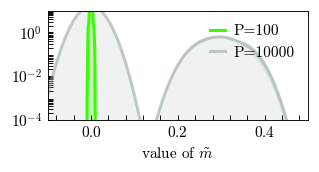

In [1]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=True):
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                return
    except Exception:
        pass

_maybe_apply_slim(theme="light", serif=True)

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------

def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")
    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = a_N.view(-1).cpu().numpy()  * (JS.view(-1).cpu().numpy())
        m_list.append(mtilde)
    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P500_kap5.000e-03_Ptr500_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__init_particles.pt"
    SNAP_B = \
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_noard_fix/5e-3/" \
        "rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev2__final_particles.pt"

    # S = (0,1,2,3)
    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=200_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-6,
        label_A="P=100", label_B="P=10000",
        width=3.0, aspect=1.8,
        x_range=(-0.1, 0.5), y_range=(1e-4,10),
        savepath="/home/goring/mean_field_langevin/plots/plots_3/pm_MF.svg",
        stride=1,
    )


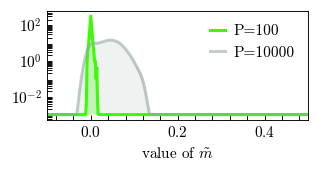

In [ ]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, but (like your plot1) show the
across-experiment mean density and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute \tilde m = (scale_f * a) * J_S(w) for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=True):
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                return
    except Exception:
        pass

_maybe_apply_slim(theme="light", serif=True)

# ---------------------------- MF helpers (from plot2) -------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(W_dN, act="relu", S=(0,1,2,3),
                                   num_samples=200_000, batch_size=100_000,
                                   device=None, seed=123):
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------

def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,)
    """
    W, a, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        W_dN = Wflat.T.contiguous().float().cpu()
        a_N  = aflat.contiguous().float().cpu()
        exps.append((W_dN, a_N))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------

def mtilde_per_experiment_from_snapshot(snapshot_path, S=(0,1,2,3), *,
                                        num_samples=200_000, batch_size=100_000,
                                        device=None, seed=123, seed_step=7,
                                        stride=1):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       Uses MF scaling: m~ = (scale_f * a) * J_S(w).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")
    m_list = []
    for k, (W_dN, a_N) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = a_N.view(-1).cpu().numpy() * (JS.view(-1).cpu().numpy())
        m_list.append(mtilde)
    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------

def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files (same as in your plot2 script)
    SNAP_A = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10_kap5.000e-03_Ptr10_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
    SNAP_B = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"

    # S = (0,1,2,3)
    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 15.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-3,
        label_A="P=100", label_B="P=10000",
        width=3.0, aspect=1.8,
        x_range=(-0.1, 0.5), y_range=None,
        savepath="/home/goring/mean_field_langevin/plots/plots_3/pm_MF_ard.svg",
        stride=1,
    )


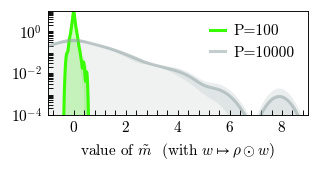

In [26]:
# -*- coding: utf-8 -*-
"""
Overlay p(~m) for TWO MF snapshots, showing the across-experiment mean density
and a ±k·std band.

Each snapshot is assumed to contain E parallel experiments (shape (E,B,⋯)).
We compute  \tilde m = a * J_S( rho ⊙ w )  for each experiment e, build a KDE
per experiment, then aggregate them with a weighted mean (weights ∝ #particles
per experiment after any stride) and an across-experiment std.

If a snapshot does not actually contain multiple experiments (e.g. saved with
experiments collapsed), we raise a descriptive error so you can fix the save.
"""

import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -------------------- (optional) slim theme if you have it --------------------
def _maybe_apply_slim(theme="light", serif=True):
    try:
        candidates = [
            "/home/goring/mean_field_langevin/plot_utils",
            "/home/goring/mean_field_langevin/plots_utils",
            os.path.join(os.getcwd(), "plot_utils"),
            os.path.join(os.getcwd(), "plots_utils"),
        ]
        for d in candidates:
            if os.path.isfile(os.path.join(d, "slim_plotters.py")):
                if d not in sys.path:
                    sys.path.insert(0, d)
                import slim_plotters as sp
                sp.apply(theme=theme, serif=serif)
                return
    except Exception:
        pass

_maybe_apply_slim(theme="light", serif=True)

# ---------------------------- MF helpers (rho ⊙ w) ----------------------------
@torch.no_grad()
def estimate_JS_for_all_neurons_MF(
    W_dN, act="relu", S=(0,1,2,3),
    rho_d=None,
    num_samples=200_000, batch_size=100_000,
    device=None, seed=123
):
    """
    Estimate J_S( rho ⊙ w ) for all neurons (columns) in W_dN.
      - W_dN: (d, N) weights (per experiment, across particles)
      - rho_d: (d,) ARD precision vector; if provided, we use W_eff = diag(rho) @ W
      - Returns: (N,)
    """
    d, N = W_dN.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(int(seed))

    # Move to device
    Wd = W_dN.to(device, non_blocking=True)  # (d,N)
    if rho_d is not None:
        rho_vec = rho_d.to(device, non_blocking=True).view(-1, 1)  # (d,1)
        Wd = rho_vec * Wd  # elementwise scale rows -> (d,N)

    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0

    B, P = int(batch_size), int(num_samples)
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True) if len(S)>0 else torch.ones(b,1,device=device)
        Z = X @ Wd                                              # (b,N)
        if act == "relu":
            Phi = F.relu(Z)
        elif act == "tanh":
            Phi = torch.tanh(Z)
        else:
            raise ValueError(f"Unsupported activation for JS: {act}")
        accum += (Phi * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------- simple 1D KDE ---------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens

# --------------------------- aggregation utils -------------------------------
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None -> equal.
    Returns mean[G], std[G] (population-style)."""
    arr = np.asarray(arr_stack, float)
    if arr.size == 0:
        return np.array([]), np.array([])
    M, G = arr.shape
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M:
            raise ValueError("weights must be a 1D array of length #experiments")
    wsum = np.sum(w)
    if not np.isfinite(wsum) or wsum <= 0:
        w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-experiment KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-exp std).
    weights='auto' -> weights ∝ len(m) for each experiment (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture over experiments
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# ---------------------- snapshot loading (per experiment) ---------------------
def _load_snapshot_raw(path, map_location="cpu"):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Snapshot not found: {path}")
    pkg = torch.load(path, map_location=map_location)
    if "params" not in pkg or "meta" not in pkg:
        raise ValueError(f"Snapshot missing keys 'params'/'meta': {path}")
    W = pkg["params"].get("W", None)
    a = pkg["params"].get("a", None)
    rho = pkg["params"].get("rho", None)
    if W is None or a is None:
        raise ValueError("Snapshot 'params' must include tensors 'W' and 'a'.")
    if rho is None:
        raise ValueError("Snapshot 'params' must include tensor 'rho' for ARD precision.")
    if W.ndim != 3 or a.ndim != 3 or a.shape[2] != 1:
        raise ValueError(
            f"Expected W:(E,B,d) and a:(E,B,1). Got W:{tuple(W.shape)} a:{tuple(a.shape)}.\n"
            "This often means the experiments were saved incorrectly or flattened."
        )
    if rho.ndim != 2 or rho.shape[1] != W.shape[2]:
        raise ValueError(f"'rho' must be (E,d). Got {tuple(rho.shape)} vs d={W.shape[2]}.")
    meta = pkg["meta"]
    act = meta.get("model", {}).get("act", None)
    scale_f = float(meta.get("scale_f", 1.0))  # not used anymore, but kept in meta
    E_meta = int(meta.get("E", W.shape[0]))
    if W.shape[0] != E_meta:
        raise ValueError(
            f"Mismatch: tensor E={W.shape[0]} but meta['E']={E_meta}. Snapshot may be inconsistent."
        )
    return W.cpu().float(), a.cpu().float(), rho.cpu().float(), act, scale_f, meta

@torch.no_grad()
def load_experiments_dN(path, *, stride=1, map_location="cpu"):
    """Return a list of (W_dN, a_N, rho_d) for each experiment e.
    - W_dN has shape (d, N_e), a_N has shape (N_e,), rho_d has shape (d,)
    """
    W, a, rho, act, scale_f, meta = _load_snapshot_raw(path, map_location)
    E, B, d = W.shape
    exps = []
    for e in range(E):
        Wflat = W[e, ::stride, :]           # (B', d)
        aflat = a[e, ::stride, 0]           # (B',)
        rho_d = rho[e]                       # (d,)
        W_dN = Wflat.T.contiguous().float().cpu()   # (d, B')
        a_N  = aflat.contiguous().float().cpu()     # (B',)
        exps.append((W_dN, a_N, rho_d))
    return exps, act, scale_f, meta

# --------------------- compute m~ lists per snapshot --------------------------
def mtilde_per_experiment_from_snapshot(
    snapshot_path, S=(0,1,2,3), *,
    num_samples=200_000, batch_size=100_000,
    device=None, seed=123, seed_step=7,
    stride=1
):
    """Compute a list of 1D numpy arrays of \tilde m for EACH experiment in a snapshot.
       NEW:  m~ = a * J_S( rho ⊙ w )   (scale_f removed; rho included).
    """
    exps, act, scale_f, meta = load_experiments_dN(snapshot_path, stride=stride)
    if act is None:
        raise ValueError("Activation kind not found in snapshot meta['model']['act'].")
    m_list = []
    for k, (W_dN, a_N, rho_d) in enumerate(exps):
        JS = estimate_JS_for_all_neurons_MF(
            W_dN, act=act, S=S, rho_d=rho_d,
            num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = a_N.view(-1).cpu().numpy() * (JS.view(-1).cpu().numpy())
        m_list.append(mtilde)
    return m_list, act, scale_f, meta

# ------------------------------ plotting -------------------------------------
def plot_mtilde_two_models_avg_over_experiments(
    snapshot_A, snapshot_B, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples=100_000, batch_size=20_000, device=None, seed_A=123, seed_B=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill ± k*std in 'mixture' mode
    # Styling
    grid_points=18001, weight_range=None,
    color_A="#39FD01", color_B="#95A5A6",
    alpha_A=1.0, alpha_B=0.55,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_A="model A (avg)", label_B="model B (avg)",
    width=3.2, aspect=1.45,
    x_range=None, y_range=None,
    savepath=None,
    stride=1
):
    """
    Average p(~m) over experiments inside each snapshot and overlay the two models.
    Shows an across-experiment band if 'mixture' and multiple experiments exist.
    \nUses:  \tilde m = a * J_S( rho ⊙ w ).
    """
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute per-experiment \tilde m ---
    mA, actA, scaleA, metaA = mtilde_per_experiment_from_snapshot(
        snapshot_A, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_A, stride=stride
    )
    mB, actB, scaleB, metaB = mtilde_per_experiment_from_snapshot(
        snapshot_B, S=S, num_samples=num_samples, batch_size=batch_size,
        device=device, seed=seed_B, stride=stride
    )

    EA = len(mA); EB = len(mB)
    if EA < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_A has E={EA} experiment(s); std band disabled.")
    if EB < 2 and show_band and avg_mode == "mixture":
        print(f"[warn] snapshot_B has E={EB} experiment(s); std band disabled.")

    # --- grid range from both sets ---
    def _concat_all(ll):
        return np.concatenate(ll) if ll else np.array([])
    all_abs = np.abs(np.concatenate([_concat_all(mA), _concat_all(mB)]))
    if weight_range is None:
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max() if all_abs.size else 1.0))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, int(grid_points))

    # --- aggregate KDEs for both models (over experiments) ---
    dA, sA = kde_aggregate(mA, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dB, sB = kde_aggregate(mB, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    ax.semilogy(grid, dA, color=color_A, lw=linewidth, alpha=alpha_A, label=label_A)
    ax.fill_between(grid, dA, density_floor, color=color_A,
                    alpha=alpha_A*fill_alpha_scale, linewidth=0)
    if show_band and (sA is not None) and np.any(sA > 0):
        loA = np.clip(dA - band_k*sA, density_floor, None)
        hiA = np.clip(dA + band_k*sA, density_floor, None)
        ax.fill_between(grid, loA, hiA, color=color_A, alpha=0.18, linewidth=0)

    ax.semilogy(grid, dB, color=color_B, lw=linewidth, alpha=alpha_B, label=label_B)
    ax.fill_between(grid, dB, density_floor, color=color_B,
                    alpha=alpha_B*fill_alpha_scale, linewidth=0)
    if show_band and (sB is not None) and np.any(sB > 0):
        loB = np.clip(dB - band_k*sB, density_floor, None)
        hiB = np.clip(dB + band_k*sB, density_floor, None)
        ax.fill_between(grid, loB, hiB, color=color_B, alpha=0.18, linewidth=0)

    ax.set_xlabel(r"value of $\tilde m$  (with $w \mapsto \rho \odot w$)")
    ax.legend(frameon=False, loc="upper right")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, bbox_inches="tight")

    return fig, {
        "grid": grid,
        "density_A": dA,
        "std_A": sA,
        "density_B": dB,
        "std_B": sB,
        "meta_A": metaA,
        "meta_B": metaB,
    }

# ------------------------------- example usage -------------------------------
if __name__ == "__main__":
    # Point these to your snapshot files
    SNAP_A = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10_kap5.000e-03_Ptr10_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"
    SNAP_B = "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_conv2_long_fin_ard_0.01_fix/5e-3/rs_aw_ard_sgld_FAST_P10000_kap5.000e-03_Ptr10000_E3_Peval100000_kap5.000e-03_T5.000e-05_N512_B512_g0.5_actrelu_f32_dev0__final_particles.pt"

    S = (0,1,2,3)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    plot_mtilde_two_models_avg_over_experiments(
        SNAP_A, SNAP_B,
        S=S,
        num_samples=100_000, batch_size=20_000, device=device,
        avg_mode="mixture", bandwidth=None, show_band=True, band_k=1.0,
        grid_points=18001, weight_range=(-15.5, 55.5),
        color_A="#39FD01", color_B="#95A5A6",
        alpha_A=1.0, alpha_B=0.55, linewidth=2.0, fill_alpha_scale=0.25,
        density_floor=1e-6,
        label_A="P=100", label_B="P=10000",
        width=3.0, aspect=1.8,
        x_range=(-1.0, 9), y_range=(1e-4,10),
        savepath="/home/goring/mean_field_langevin/plots/plots_3/pm_MF_ard.svg",
        stride=1,
    )


[init] loading & sampling from 3 models...
[final] loading & sampling from 3 models...


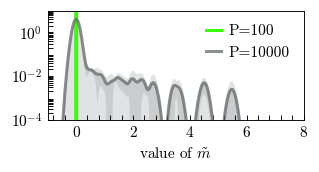

In [27]:
# ----------------------------------------------------------------------------- #
# Multi-model helpers for m~ = a * J_S(w)   (init vs final groups)
# ----------------------------------------------------------------------------- #
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

def load_many_WA(model_paths, map_location="cpu"):
    Ws, As = [], []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(f"Incompatible d across models: {d_ref} vs {W.shape[0]} for {p}")
        Ws.append(W)
        As.append(a)
    return Ws, As  # lists of tensors


def estimate_JS_for_all_neurons(W, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                device=None, seed=123):
    d, N = W.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(seed)
    Wd = W.to(device, non_blocking=True)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0
    B, P = batch_size, num_samples
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True)   # (b,1)
        Z = F.relu(X @ Wd)                              # (b,N)
        accum += (Z * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

@torch.no_grad()
def mtilde_list_from_models(model_paths, S=(0,1,2,3), *,
                            num_samples=200_000, batch_size=100_000,
                            device=None, seed=123, seed_step=7):
    """Return list of numpy arrays of \tilde m for each model."""
    Ws, As = load_many_WA(model_paths, map_location="cpu")
    mts = []
    for k, (W, a) in enumerate(zip(Ws, As)):
        JS = estimate_JS_for_all_neurons(
            W, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = (a.view(-1).cpu().numpy()) * (JS.view(-1).cpu().numpy())
        mts.append(mtilde)
    return mts  # list of 1D numpy arrays

# --------------------------- KDE aggregators --------------------------------- #
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None (equal)."""
    arr = np.asarray(arr_stack, float)
    M, G = arr.shape
    if M == 0:
        return np.zeros(G), np.zeros(G)
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M: raise ValueError("weights must match #models")
    wsum = np.sum(w)
    if wsum <= 0: w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)  # population-style
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-model KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-run std).
    weights='auto' -> weights ∝ len(m) for each model (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture: per-model densities, then weighted mean/std
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# --------------------------- Plot: two groups -------------------------------- #
def plot_mtilde_two_groups_multi_models(
    init_model_paths, final_model_paths, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000, device=None, seed_init=123, seed_final=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill +/- k*std in 'mixture' mode
    # Styling
    grid_points=2001, weight_range=None,
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_init="init", label_final="final",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pm_NN.svg"
):
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute all \tilde m samples ---
    print(f"[init] loading & sampling from {len(init_model_paths)} models...")
    m_init = mtilde_list_from_models(
        init_model_paths, S=S,
        num_samples=num_samples_init, batch_size=batch_size,
        device=device, seed=seed_init
    )
    print(f"[final] loading & sampling from {len(final_model_paths)} models...")
    m_final = mtilde_list_from_models(
        final_model_paths, S=S,
        num_samples=num_samples_final, batch_size=batch_size,
        device=device, seed=seed_final
    )

    # --- grid range ---
    if weight_range is None:
        all_abs = np.abs(np.concatenate([np.concatenate(m_init), np.concatenate(m_final)])) \
                  if (m_init and m_final) else np.array([1.0])
        hi = float(np.quantile(all_abs, 0.995))
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    # --- aggregate KDEs for both groups ---
    dI, sI = kde_aggregate(m_init, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dF, sF = kde_aggregate(m_final, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    # INIT
    ax.semilogy(grid, dI, color=color_init, lw=linewidth, alpha=alpha_init, label=label_init)
    ax.fill_between(grid, dI, density_floor, color=color_init,
                    alpha=alpha_init*fill_alpha_scale, linewidth=0)
    if show_band and sI is not None and np.any(sI > 0):
        loI = np.clip(dI - band_k*sI, density_floor, None)
        hiI = np.clip(dI + band_k*sI, density_floor, None)
        ax.fill_between(grid, loI, hiI, color=color_init, alpha=0.18, linewidth=0)

    # FINAL
    ax.semilogy(grid, dF, color=color_final, lw=linewidth, alpha=alpha_final, label=label_final)
    ax.fill_between(grid, dF, density_floor, color=color_final,
                    alpha=alpha_final*fill_alpha_scale, linewidth=0)
    if show_band and sF is not None and np.any(sF > 0):
        loF = np.clip(dF - band_k*sF, density_floor, None)
        hiF = np.clip(dF + band_k*sF, density_floor, None)
        ax.fill_between(grid, loF, hiF, color=color_final, alpha=0.18, linewidth=0)

    # Labels/legend
    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    # Minor ticks: bottom & left only
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig



# --- Provide your model lists ---
INIT_MODELS = [
  "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]
FINAL_MODELS = [
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]

# Fallback examples (edit directories as needed)
if not INIT_MODELS or not FINAL_MODELS:
    BASE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    # just examples of picking 5 oldest as "init" and 5 newest as "final"
    all_pts = sorted(glob.glob(os.path.join(BASE, "final_model_*.pt")), key=os.path.getmtime)
    INIT_MODELS = all_pts[:5]
    FINAL_MODELS = all_pts[-5:]

_ = plot_mtilde_two_groups_multi_models(
    INIT_MODELS, FINAL_MODELS,
    S=(0,1,2,3),
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed_init=123, seed_final=456,
    avg_mode="mixture",         # <- true mean of per-model densities
    bandwidth=None,             # <- use Scott per model; set float to fix bw
    show_band=True, band_k=1.0, # <- ±1σ band across runs (mixture mode)
    grid_points=6001, weight_range=(-15,15),
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_init="P=100", label_final="P=10000",
    width=3.0, aspect=1.8,
        x_range=(-1, 8), y_range=(1e-4,10),
)


[init] loading & sampling from 3 models...
[final] loading & sampling from 3 models...


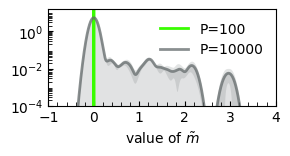

In [5]:
import os, sys, math, glob
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1) if n > 1 else 0.0
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens
# ----------------------------------------------------------------------------- #
# Multi-model helpers for m~ = a * J_S(w)   (init vs final groups)
# ----------------------------------------------------------------------------- #
def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

def load_many_WA(model_paths, map_location="cpu"):
    Ws, As = [], []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(f"Incompatible d across models: {d_ref} vs {W.shape[0]} for {p}")
        Ws.append(W)
        As.append(a)
    return Ws, As  # lists of tensors


def estimate_JS_for_all_neurons(W, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                device=None, seed=123):
    d, N = W.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(seed)
    Wd = W.to(device, non_blocking=True)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0
    B, P = batch_size, num_samples
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True)   # (b,1)
        Z = F.sigmoid(X @ Wd)                              # (b,N)
        accum += (Z * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

@torch.no_grad()
def mtilde_list_from_models(model_paths, S=(0,1,2,3), *,
                            num_samples=200_000, batch_size=100_000,
                            device=None, seed=123, seed_step=7):
    """Return list of numpy arrays of \tilde m for each model."""
    Ws, As = load_many_WA(model_paths, map_location="cpu")
    mts = []
    for k, (W, a) in enumerate(zip(Ws, As)):
        JS = estimate_JS_for_all_neurons(
            W, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = (a.view(-1).cpu().numpy()) * (JS.view(-1).cpu().numpy())
        mts.append(mtilde)
    return mts  # list of 1D numpy arrays

# --------------------------- KDE aggregators --------------------------------- #
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None (equal)."""
    arr = np.asarray(arr_stack, float)
    M, G = arr.shape
    if M == 0:
        return np.zeros(G), np.zeros(G)
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M: raise ValueError("weights must match #models")
    wsum = np.sum(w)
    if wsum <= 0: w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)  # population-style
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-model KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-run std).
    weights='auto' -> weights ∝ len(m) for each model (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture: per-model densities, then weighted mean/std
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# --------------------------- Plot: two groups -------------------------------- #
def plot_mtilde_two_groups_multi_models(
    init_model_paths, final_model_paths, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000, device=None, seed_init=123, seed_final=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill +/- k*std in 'mixture' mode
    # Styling
    grid_points=2001, weight_range=None,
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_init="init", label_final="final",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None,
    savepath="/home/goring/mean_field_langevin/plots/plots_3/pm_NN.svg"
):
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute all \tilde m samples ---
    print(f"[init] loading & sampling from {len(init_model_paths)} models...")
    m_init = mtilde_list_from_models(
        init_model_paths, S=S,
        num_samples=num_samples_init, batch_size=batch_size,
        device=device, seed=seed_init
    )
    print(f"[final] loading & sampling from {len(final_model_paths)} models...")
    m_final = mtilde_list_from_models(
        final_model_paths, S=S,
        num_samples=num_samples_final, batch_size=batch_size,
        device=device, seed=seed_final
    )

    # --- grid range ---
    if weight_range is None:
        all_abs = np.abs(np.concatenate([np.concatenate(m_init), np.concatenate(m_final)])) \
                  if (m_init and m_final) else np.array([1.0])
        hi = float(np.quantile(all_abs, 0.995))
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    # --- aggregate KDEs for both groups ---
    dI, sI = kde_aggregate(m_init, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dF, sF = kde_aggregate(m_final, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    # INIT
    ax.semilogy(grid, dI, color=color_init, lw=linewidth, alpha=alpha_init, label=label_init)
    ax.fill_between(grid, dI, density_floor, color=color_init,
                    alpha=alpha_init*fill_alpha_scale, linewidth=0)
    if show_band and sI is not None and np.any(sI > 0):
        loI = np.clip(dI - band_k*sI, density_floor, None)
        hiI = np.clip(dI + band_k*sI, density_floor, None)
        ax.fill_between(grid, loI, hiI, color=color_init, alpha=0.18, linewidth=0)

    # FINAL
    ax.semilogy(grid, dF, color=color_final, lw=linewidth, alpha=alpha_final, label=label_final)
    ax.fill_between(grid, dF, density_floor, color=color_final,
                    alpha=alpha_final*fill_alpha_scale, linewidth=0)
    if show_band and sF is not None and np.any(sF > 0):
        loF = np.clip(dF - band_k*sF, density_floor, None)
        hiF = np.clip(dF + band_k*sF, density_floor, None)
        ax.fill_between(grid, loF, hiF, color=color_final, alpha=0.18, linewidth=0)

    # Labels/legend
    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    # Minor ticks: bottom & left only
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig



# --- Provide your model lists ---
INIT_MODELS = [
  "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/init_model_P_10000_d_35_k_3_exp_0_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/init_model_P_10000_d_35_k_3_exp_1_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/init_model_P_10000_d_35_k_3_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]
FINAL_MODELS = [
    "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_0_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_1_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_rebuttal/d35_k3_sig/d35_k3/final_model_P_10000_d_35_k_3_exp_2_kappa_0.005000_eta0_2.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]

# Fallback examples (edit directories as needed)
if not INIT_MODELS or not FINAL_MODELS:
    BASE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    # just examples of picking 5 oldest as "init" and 5 newest as "final"
    all_pts = sorted(glob.glob(os.path.join(BASE, "final_model_*.pt")), key=os.path.getmtime)
    INIT_MODELS = all_pts[:5]
    FINAL_MODELS = all_pts[-5:]

_ = plot_mtilde_two_groups_multi_models(
    INIT_MODELS, FINAL_MODELS,
    S=(0,1,2),
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed_init=123, seed_final=456,
    avg_mode="mixture",         # <- true mean of per-model densities
    bandwidth=None,             # <- use Scott per model; set float to fix bw
    show_band=True, band_k=1.0, # <- ±1σ band across runs (mixture mode)
    grid_points=8001, weight_range=(-15,15),
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_init="P=100", label_final="P=10000",
    width=3.0, aspect=1.8,
        x_range=(-1, 4), y_range=(1e-4,15),
)
